In [1]:
#Installing necessary libraries
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


In [2]:
#Importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Importing the data
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv', on_bad_lines = 'skip', engine = 'python')
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [5]:
#Display basic structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [6]:
#Finding the shape of the data
print('Shape :', df.shape)
print('Rows :', df.shape[0])
print('Columns :', df.shape[1])

Shape : (4340, 8)
Rows : 4340
Columns : 8


In [7]:
#Checking if there are any null values in the data
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [8]:
#Check for the duplicates in data
df.duplicated().sum()

np.int64(763)

In [9]:
#Check for the duplicates in data
dup_value_tf=df.duplicated().sum()
if(dup_value_tf):
  print('There are duplicate values in the data')
else:
  print('No duplicate values in the data')

There are duplicate values in the data


In [10]:
# Check the duplicate data
df[df.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
13,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
14,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
15,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
16,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
17,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4307,Mahindra Xylo H4,2019,599000,15000,Diesel,Individual,Manual,Third Owner
4308,Maruti Alto 800 LXI,2018,200000,35000,Petrol,Individual,Manual,First Owner
4309,Datsun GO Plus T,2017,350000,10171,Petrol,Dealer,Manual,First Owner
4310,Renault Duster 110PS Diesel RxL,2015,465000,41123,Diesel,Dealer,Manual,First Owner


In [11]:
#Drop duplicates
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(3577, 8)

In [13]:
#Identify Numerical and Categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['year', 'selling_price', 'km_driven'], dtype='object')
Categorical Columns: Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object')


In [14]:
correlation_matrix = df.corr(numeric_only = True)
correlation_matrix['selling_price'].sort_values(ascending = False)

,selling_price
selling_price,1.000000
year,0.424260
km_driven,-0.187359


In [15]:
#Encode categorical variables
df['owner'] = df['owner'].replace({'Fourth & Above Owner': '4th_Owner'})
categorical_cols = ['fuel', 'seller_type', 'transmission','owner']

In [16]:
# Encode categorical variables using one-hot encoding for modeling
df_encoded = pd.get_dummies(df, columns=categorical_cols)
df_encoded = df_encoded.replace({False : 0, True : 1})
df_encoded.head()

,name,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_4th_Owner,owner_First Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti 800 AC,2007,60000,70000,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0
3,Datsun RediGO T Option,2017,250000,46000,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0


In [17]:
#Average selling price by name
average_selling_price = df_encoded.groupby('name')['selling_price'].mean()
print("Average Selling Price:", average_selling_price)

Average Selling Price: name
Ambassador CLASSIC 1500 DSL AC           120000.0
Ambassador Classic 2000 Dsz               50000.0
Ambassador Grand 1800 ISZ MPFI PW CL     430000.0
Audi A4 1.8 TFSI                        1200000.0
Audi A4 2.0 TDI                         1295000.0
                                          ...    
Volkswagen Vento Petrol Highline AT      284500.0
Volvo V40 D3 R Design                   1975000.0
Volvo XC 90 D5 Inscription BSIV         4500000.0
Volvo XC60 D3 Kinetic                   1750000.0
Volvo XC60 D5 Inscription               2000000.0
Name: selling_price, Length: 1491, dtype: float64


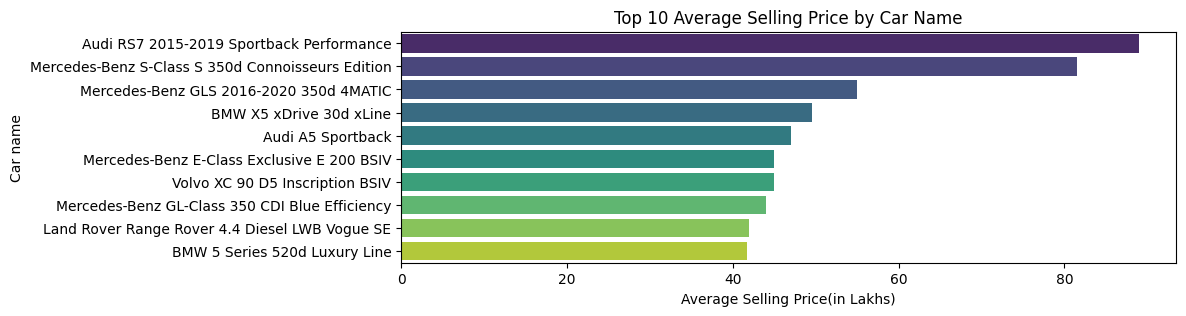

In [18]:
#Visualization on top 10 average selling price by cars
top_10_average_selling_price = average_selling_price.sort_values(ascending=False).head(10)
plt.figure(figsize = (10, 3))
sns.barplot(x = list(top_10_average_selling_price.values/100000), y = list(top_10_average_selling_price.keys()), palette = 'viridis')
plt.title('Top 10 Average Selling Price by Car Name')
plt.xlabel('Average Selling Price(in Lakhs)')
plt.ylabel('Car name')
plt.show()

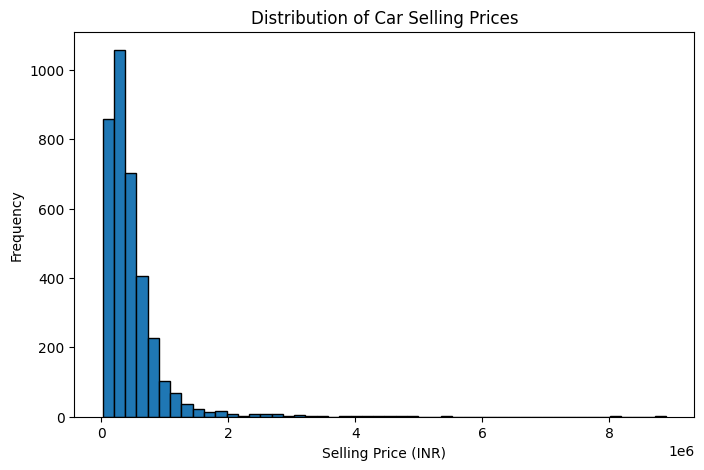

In [19]:
#Selling price distribution
plt.figure(figsize=(8,5))
plt.hist(df_encoded["selling_price"], bins=50, edgecolor="k")
plt.xlabel("Selling Price (INR)")
plt.ylabel("Frequency")
plt.title("Distribution of Car Selling Prices")
plt.show()

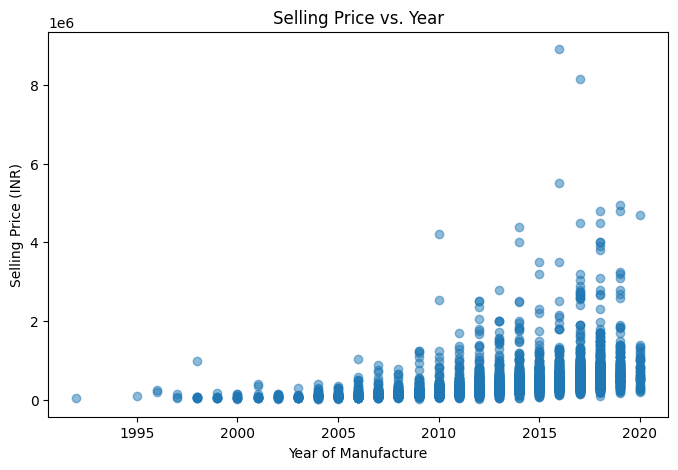

In [20]:
# Relationship: selling_price vs year
plt.figure(figsize=(8,5))
plt.scatter(df_encoded["year"], df_encoded["selling_price"], alpha=0.5)
plt.xlabel("Year of Manufacture")
plt.ylabel("Selling Price (INR)")
plt.title("Selling Price vs. Year")
plt.show()

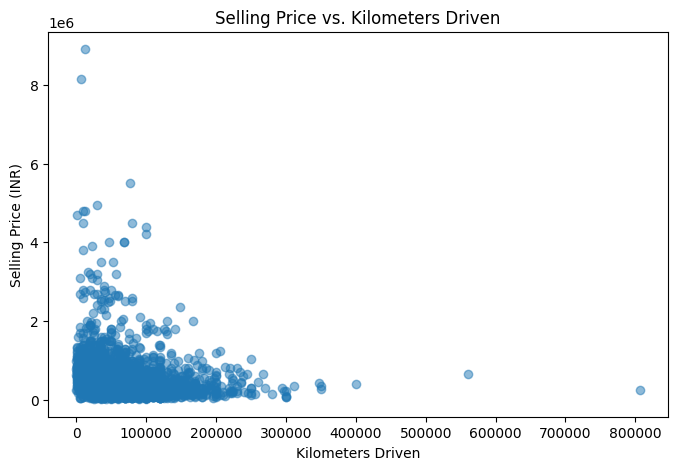

In [21]:
# Relationship: selling_price vs km_driven
plt.figure(figsize=(8,5))
plt.scatter(df_encoded["km_driven"], df_encoded["selling_price"], alpha=0.5)
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (INR)")
plt.title("Selling Price vs. Kilometers Driven")
plt.show()

<Figure size 1500x900 with 0 Axes>

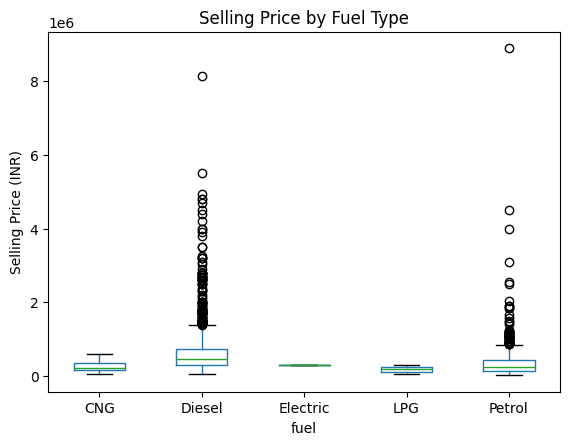

In [29]:
# Categorical impact: Boxplots for fuel, transmission, seller_type
plt.figure(figsize=(15,9))
df.boxplot(column="selling_price", by="fuel", grid=False)
plt.title("Selling Price by Fuel Type")
plt.suptitle("")
plt.ylabel("Selling Price (INR)")
plt.show()

<Figure size 800x500 with 0 Axes>

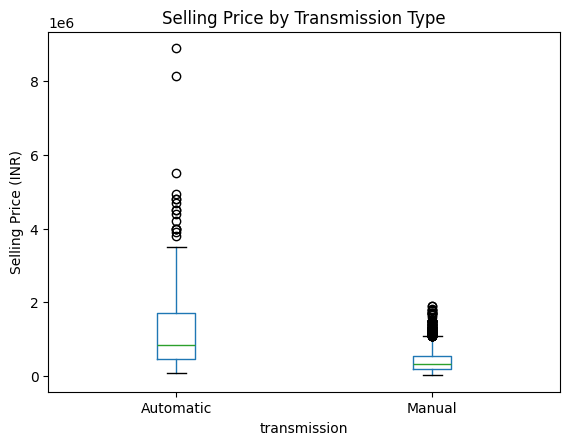

In [30]:
plt.figure(figsize=(8,5))
df.boxplot(column="selling_price", by="transmission", grid=False)
plt.title("Selling Price by Transmission Type")
plt.suptitle("")
plt.ylabel("Selling Price (INR)")
plt.show()

<Figure size 800x500 with 0 Axes>

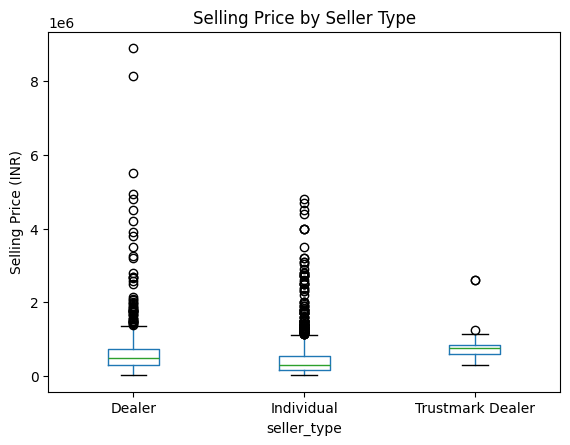

In [31]:
plt.figure(figsize=(8,5))
df.boxplot(column="selling_price", by="seller_type", grid=False)
plt.title("Selling Price by Seller Type")
plt.suptitle("")
plt.ylabel("Selling Price (INR)")
plt.show()

In [32]:
# Remove outliers
Q1 = df_encoded["selling_price"].quantile(0.25)
Q3 = df_encoded["selling_price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_encoded = df_encoded[(df_encoded["selling_price"] >= lower_bound) & (df_encoded["selling_price"] <= upper_bound)]
df_encoded.shape

(3407, 19)

In [33]:
# Get current year from pd
current_year = pd.Timestamp.now().year
df_encoded['car_age'] = current_year - df_encoded['year']

In [ ]:
#Model Building Performing train test split

In [35]:
# Features and Target
X = df_encoded.drop(columns=['name', 'year', 'selling_price'])  # Features
y = df_encoded['selling_price']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
numeric_cols = ['km_driven', 'car_age']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train = X_train.select_dtypes(include = ['number'])
X_test = X_test.select_dtypes(include = ['number'])

In [36]:
# Define lighter models
models = {
    "CatBoost": CatBoostRegressor(iterations=300, depth=8, learning_rate=0.1, random_seed=42, verbose=50),
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=50, max_depth=10),
    "GradientBoosting": GradientBoostingRegressor(random_state=42, n_estimators=100, max_depth=3)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if name == "RandomForest":
        cv_rf = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
        results[name] = {
        "R2": round(r2_score(y_test, y_pred), 2),
        "MSE": round(mean_squared_error(y_test, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        "CV_MSE": round(-cv_rf.mean(), 2)
        }

    else:
     results[name] = {
        "R2": round(r2_score(y_test, y_pred), 2),
        "MSE": round(mean_squared_error(y_test, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        "CV_MSE": 0
    }

results_df = pd.DataFrame(results)
results_df.head()

0:	learn: 242280.2297926	total: 50.6ms	remaining: 15.1s
50:	learn: 156637.2151799	total: 230ms	remaining: 1.12s
100:	learn: 150456.2187524	total: 389ms	remaining: 767ms
150:	learn: 146292.8927887	total: 688ms	remaining: 679ms
200:	learn: 142275.6318811	total: 951ms	remaining: 469ms
250:	learn: 139274.0327276	total: 1.07s	remaining: 210ms
299:	learn: 136490.4462819	total: 1.34s	remaining: 0us


,CatBoost,LinearRegression,RandomForest,GradientBoosting
R2,5.600000e-01,5.300000e-01,5.600000e-01,5.900000e-01
MSE,2.703560e+10,2.891851e+10,2.714119e+10,2.522817e+10
RMSE,1.644251e+05,1.700544e+05,1.647458e+05,1.588338e+05
CV_MSE,0.000000e+00,0.000000e+00,3.011912e+10,0.000000e+00


In [ ]:
#Hyperparameter Tuning using GridSearchCV for Gradient Boosting

In [37]:
# Hyperparameter tuning for Gradient boosting
param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

In [38]:
# Grid search for Gradient Boost
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gradient_boosting_model, param_grid, cv=3, scoring='r2', n_jobs=-1)

In [39]:
# Fit grid search to data
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [40]:
# Best parameters and best score
best_params = grid_search.best_params_
best_gradient_boosting_model = grid_search.best_estimator_
best_score = grid_search.best_score_

In [41]:
# Predict with best model
y_pred_best_gb = best_gradient_boosting_model.predict(X_test)

In [42]:
# Evaluate the best model
best_gb_results = {
    "Best Params": best_params,
    "R2": round(r2_score(y_test, y_pred_best_gb), 2),
    "MSE": round(mean_squared_error(y_test, y_pred_best_gb), 2),
    "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_best_gb)), 2)
}

In [43]:
# print best_gb_results in table manner
best_gb_results = pd.DataFrame(best_gb_results)
best_gb_results.head()

,Best Params,R2,MSE,RMSE
learning_rate,0.01,0.59,2.534154e+10,159190.28
max_depth,3.00,0.59,2.534154e+10,159190.28
n_estimators,300.00,0.59,2.534154e+10,159190.28


In [44]:
print('Best Model :', best_gradient_boosting_model)
print('Best Parameters :', best_params)
print('Best Score (r2) :', round(best_score, 2))

Best Model : GradientBoostingRegressor(learning_rate=0.01, n_estimators=300, random_state=42)
Best Parameters : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Best Score (r2) : 0.56


In [ ]:
#Hyperparameter Tuning using GridSearchCV for Cat Boost

In [45]:
# Define parameter grid for CatBoost
param_grid = {
    'iterations': [200, 300],
    'depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1, 0.15],
    'random_seed': [42]
}

In [46]:
# Grid search for CatBoost
catboost_model = CatBoostRegressor(verbose=1, random_seed=42)
grid_search = GridSearchCV(catboost_model, param_grid, cv=3, scoring='r2', n_jobs=-1)

In [47]:
# Fit grid search to data
grid_search.fit(X_train, y_train)

0:	learn: 248509.6493583	total: 1.37ms	remaining: 273ms
1:	learn: 243037.1837213	total: 2.69ms	remaining: 267ms
2:	learn: 237516.6669567	total: 3.72ms	remaining: 244ms
3:	learn: 232295.9717856	total: 4.69ms	remaining: 230ms
4:	learn: 227857.1679757	total: 5.63ms	remaining: 220ms
5:	learn: 223306.3525470	total: 6.57ms	remaining: 212ms
6:	learn: 218946.9881906	total: 7.53ms	remaining: 208ms
7:	learn: 215113.8196240	total: 8.49ms	remaining: 204ms
8:	learn: 211440.4332110	total: 9.44ms	remaining: 200ms
9:	learn: 208132.0228929	total: 10.4ms	remaining: 198ms
10:	learn: 204843.7281221	total: 11.3ms	remaining: 195ms
11:	learn: 201972.7683669	total: 12.3ms	remaining: 193ms
12:	learn: 199255.2565583	total: 13.3ms	remaining: 191ms
13:	learn: 196895.2632589	total: 14.3ms	remaining: 190ms
14:	learn: 194869.0758262	total: 14.9ms	remaining: 184ms
15:	learn: 192906.3347857	total: 15.8ms	remaining: 182ms
16:	learn: 190897.0372541	total: 16.8ms	remaining: 181ms
17:	learn: 189184.0847089	total: 17.7ms	r

GridSearchCV(cv=3,
             estimator=<catboost.core.CatBoostRegressor object at 0x7a762f058bc0>,
             n_jobs=-1,
             param_grid={'depth': [6, 8, 10], 'iterations': [200, 300],
                         'learning_rate': [0.05, 0.1, 0.15],
                         'random_seed': [42]},
             scoring='r2')

In [48]:
# Best parameters and best score
best_params = grid_search.best_params_
best_catboost_model = grid_search.best_estimator_
best_score = grid_search.best_score_

In [49]:
# Predict with best model
y_pred_best_catboost = best_catboost_model.predict(X_test)

In [50]:
# Evaluate the best CatBoost model
best_catboost_results = {
    "Best Params": best_params,
    "R2": round(r2_score(y_test, y_pred_best_catboost), 2),
    "MSE": round(mean_squared_error(y_test, y_pred_best_catboost), 2),
    "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_best_catboost)), 2)
}

In [51]:
# print best_catboost_results in table manner
best_catboost_results = pd.DataFrame(best_catboost_results)
best_catboost_results.head()

,Best Params,R2,MSE,RMSE
depth,6.00,0.6,2.466385e+10,157047.29
iterations,200.00,0.6,2.466385e+10,157047.29
learning_rate,0.05,0.6,2.466385e+10,157047.29
random_seed,42.00,0.6,2.466385e+10,157047.29


In [52]:
#Creating optimal model
y_pred_best = best_catboost_results['R2'].iloc[0]
print('Best Model :', best_catboost_model)
print('Best Parameters :', best_params)
print('Best Score (r2) :', round(y_pred_best, 2))

Best Model : <catboost.core.CatBoostRegressor object at 0x7a762f84dfa0>
Best Parameters : {'depth': 6, 'iterations': 200, 'learning_rate': 0.05, 'random_seed': 42}
Best Score (r2) : 0.6


In [ ]:
#Model training using best params

In [53]:
# Models to train
gradient_boosting_model = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.01)
catboost_model = CatBoostRegressor(iterations=200, depth=6, learning_rate=0.05, random_seed=42)

In [54]:
# Fit models
gradient_boosting_model.fit(X_train, y_train)
catboost_model.fit(X_train, y_train)

0:	learn: 248509.6493583	total: 1.11ms	remaining: 221ms
1:	learn: 243037.1837213	total: 4.7ms	remaining: 465ms
2:	learn: 237516.6669567	total: 7.84ms	remaining: 515ms
3:	learn: 232295.9717856	total: 10.4ms	remaining: 508ms
4:	learn: 227857.1679757	total: 12.9ms	remaining: 502ms
5:	learn: 223306.3525470	total: 15.9ms	remaining: 514ms
6:	learn: 218946.9881906	total: 19.6ms	remaining: 540ms
7:	learn: 215113.8196240	total: 22.6ms	remaining: 543ms
8:	learn: 211440.4332110	total: 24ms	remaining: 510ms
9:	learn: 208132.0228929	total: 28.5ms	remaining: 541ms
10:	learn: 204843.7281221	total: 32.8ms	remaining: 564ms
11:	learn: 201972.7683669	total: 36.2ms	remaining: 568ms
12:	learn: 199255.2565583	total: 38.8ms	remaining: 558ms
13:	learn: 196895.2632589	total: 42.2ms	remaining: 560ms
14:	learn: 194869.0758262	total: 43.9ms	remaining: 542ms
15:	learn: 192906.3347857	total: 45.2ms	remaining: 520ms
16:	learn: 190897.0372541	total: 49ms	remaining: 527ms
17:	learn: 189184.0847089	total: 52.3ms	remain

In [55]:
# Make predictions
y_pred_gb = gradient_boosting_model.predict(X_test)
y_pred_catboost = catboost_model.predict(X_test)

In [56]:
# Evaluate models
metrics_comparison = {
    "Gradient Boosting": {
        "R²": round(r2_score(y_test, y_pred_gb), 2),
        "MSE": round(mean_squared_error(y_test, y_pred_gb), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_gb)), 2)
    },
    "CatBoost": {
        "R²": round(r2_score(y_test, y_pred_catboost), 2),
        "MSE": round(mean_squared_error(y_test, y_pred_catboost), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_catboost)), 2)
    }
}

In [57]:
metrics_comparison_df = pd.DataFrame(metrics_comparison).T
metrics_comparison_df.head()

,R²,MSE,RMSE
Gradient Boosting,0.59,2.534023e+10,159186.14
CatBoost,0.60,2.466385e+10,157047.29


In [ ]:
#Visualize Predicted vs Actual for Gradient Boosting model

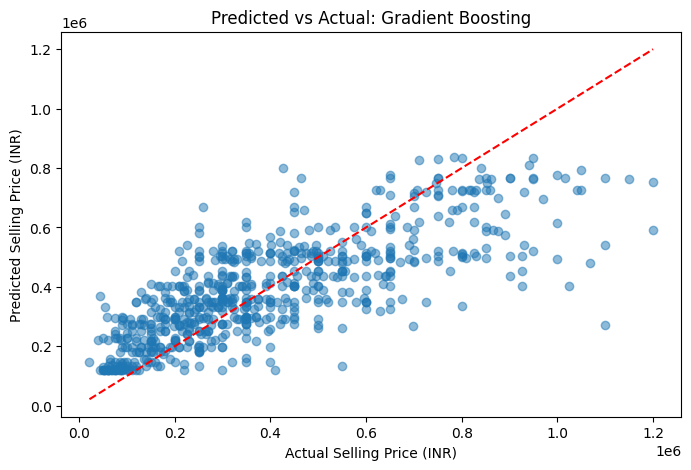

In [58]:
# Visualize Predicted vs Actual for GB  model
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_gb, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual Selling Price (INR)")
plt.ylabel("Predicted Selling Price (INR)")
plt.title("Predicted vs Actual: Gradient Boosting")
plt.show()

In [ ]:
#Visualize Predicted vs Actual for CatBoost model

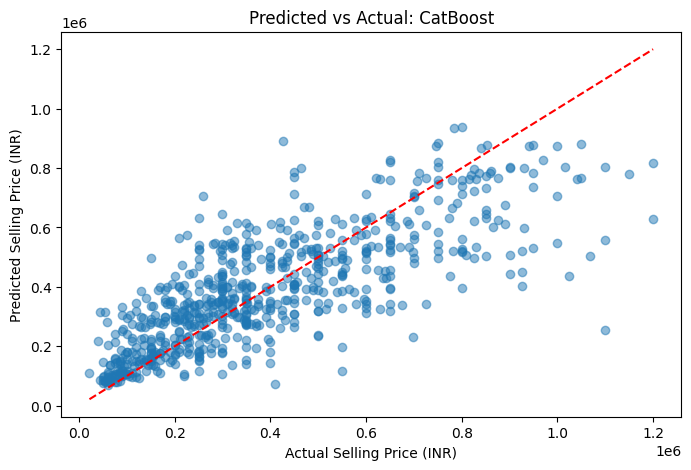

In [59]:
# Visualize Predicted vs Actual for CB model
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_catboost, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual Selling Price (INR)")
plt.ylabel("Predicted Selling Price (INR)")
plt.title("Predicted vs Actual: CatBoost")
plt.show()

In [60]:
# Saving the model in PICKLE file format
import pickle
pickle.dump(catboost_model, open('catboost_model.pkl', 'wb'))